In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *
from python.misprediction_classifier import *
from autoencoder.src.data_loader import *
from interpolate import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Polar interpolation

## eval function

In [2]:
def eval_interpolation(interpolator, pts, verbose=False):
    """
    Evaluate the interpolation performance of a given interpolator.
    
    Args:
        interpolator: The interpolator to evaluate.
        pts: The points to interpolate.
        gt_pts: The ground truth points.
        
    Returns:
        The interpolation error.
    """
    pts = pts[:, :, :2]
    frame_cnt, pt_cnt = pts.shape[:2]
    interpolation_err = np.zeros((frame_cnt, pt_cnt))
    
    for frame_idx in range(frame_cnt):
        if verbose: 
            print(f'frame_idx: {frame_idx}')
        curr_frame_pts = pts[frame_idx]
        polygon_order = poly_4(curr_frame_pts)
        curr_frame_pts = curr_frame_pts[polygon_order]
        center_pos = curr_frame_pts.mean(axis=0)
        
        for pt_idx in range(pt_cnt):
            
            curr_pt = curr_frame_pts[pt_idx]
            curr_frame_curr_pt = curr_frame_pts.copy()
            curr_frame_curr_pt[pt_idx] = (0, 0)
            curr_pt_interpolated = interpolator(curr_frame_curr_pt, frame_idx=frame_idx, center_pos=center_pos, verbose=False)[pt_idx]
            assert curr_pt.shape == curr_pt_interpolated.shape, f'shape mismatch: {curr_pt.shape} != {curr_pt_interpolated.shape}'
            interpolation_err[frame_idx, pt_idx] = np.linalg.norm(curr_pt - curr_pt_interpolated)
            if verbose:
                print(f'curr_pt: {np.round(curr_pt, 2)}, curr_pt_interpolated: {np.round(curr_pt_interpolated, 2)}, err: {np.round(interpolation_err[frame_idx, pt_idx], 2)}')
            
    return interpolation_err

In [3]:
corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 981.51it/s]

Missing point count: 0
reorder_idx.shape: (17,)


## polar interpolate function

In [26]:
frame0_pts = gt_pts[2]
frame0_polygon_order = poly_4(frame0_pts)
frame0_pts = frame0_pts[frame0_polygon_order]

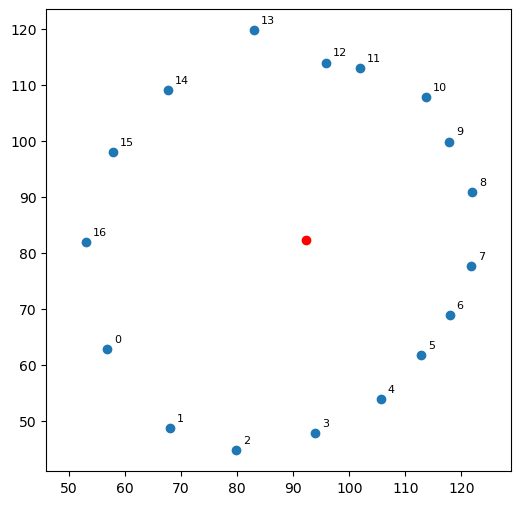

In [15]:
center_pos = frame0_pts.mean(axis=0)
plt.figure(figsize=(6, 6))  # Make plot larger for better label visibility

# Plot points and center
plt.scatter(frame0_pts[:, 0], frame0_pts[:, 1])
plt.scatter(center_pos[0], center_pos[1], color='red')

# Add index labels with slight offset
for i, (x, y) in enumerate(frame0_pts):
    plt.annotate(str(i), (x, y), 
                xytext=(5, 5),  # 5 points offset
                textcoords='offset points',
                fontsize=8)

plt.axis('equal')  # Keep aspect ratio equal
plt.show()

In [27]:
missing_idx = 13
frame0_pts_copy = frame0_pts.copy()
frame0_pts_copy[missing_idx] = (0, 0)
frame0_pts_interpolated = polar_interpolate(frame0_pts_copy)
print(f'true coords of pt {missing_idx}: {frame0_pts[missing_idx]}')
print(f'interpolated coords of pt {missing_idx}: {frame0_pts_interpolated[missing_idx]}')
frame0_pts_interpolated

prev_idx: 12, next_idx: 14
r1: 34.03232886282931, theta1: 85.03106384083637
r2: 38.45438643810924, theta2: 131.12496848009783
weight: 0.5
theta1: 85.03106384083637, theta2: 131.12496848009783
r_interp: 36.24335765046928, theta_interp: 108.07801616046712
n1: [ 95.81559753 113.93301392], n2: [ 67.57627869 108.99538422]
cart_interpolated_pts: [ 81.621128   114.48278461]
true coords of pt 13: [ 82.98293304 119.68743896]
interpolated coords of pt 13: [ 81.621128   114.48278461]


array([[ 56.8390274 ,  62.87812805],
       [ 67.929245  ,  48.65399551],
       [ 79.79259491,  44.7642746 ],
       [ 93.87147522,  47.882164  ],
       [105.60311127,  53.87807465],
       [112.83431244,  61.77319336],
       [117.91784668,  68.8447113 ],
       [121.6602478 ,  77.59156799],
       [121.91754913,  90.85507202],
       [117.80519104,  99.83609009],
       [113.6468277 , 107.78422546],
       [101.89625549, 112.92688751],
       [ 95.81559753, 113.93301392],
       [ 81.621128  , 114.48278461],
       [ 67.57627869, 108.99538422],
       [ 57.835495  ,  97.93512726],
       [ 52.94480133,  81.92545319]])

In [4]:
def plot_pred_vs_gt_pts(pred_pts, gt_pts, center_pos=None, canvas_size=(170, 170)):
    assert pred_pts.shape == gt_pts.shape, f'shape mismatch: {pred_pts.shape} != {gt_pts.shape}'
    if center_pos is None:
        center_pos = gt_pts.mean(axis=0)
        
    plt.axis('equal')
    plt.scatter(gt_pts[:, 0], gt_pts[:, 1], color='green', label='true')
    plt.scatter(pred_pts[:, 0], pred_pts[:, 1], color='blue', label='interpolated')
    plt.scatter(center_pos[0], center_pos[1], color='red')
    
    for i, (x, y) in enumerate(gt_pts):
        plt.annotate(str(i), (x, y), 
                    xytext=(5, 5),  # 5 points offset
                    textcoords='offset points',
                    fontsize=8)
     
    plt.legend(fontsize=8, bbox_to_anchor=(1, 1))
    plt.axis('equal')
    plt.show()
    
def test_single_frame_polar_interpolation(gt_pts, frame_idx):
    curr_frame_pts = gt_pts[frame_idx]
    poly_order = poly_4(curr_frame_pts)
    curr_frame_pts = curr_frame_pts[poly_order]
    interp_pts = np.zeros_like(curr_frame_pts)
    for pt_idx in range(curr_frame_pts.shape[0]):
        curr_frame_pts_copy = curr_frame_pts.copy()
        curr_frame_pts_copy[pt_idx] = (0, 0)
        interp_pts[pt_idx] = polar_interpolate(curr_frame_pts_copy, verbose=False)[pt_idx]
    plot_pred_vs_gt_pts(interp_pts, curr_frame_pts)
    mean_err = np.linalg.norm(interp_pts - curr_frame_pts, axis=1).mean()
    print(f'mean error (pixel): {mean_err:.2f}')

    

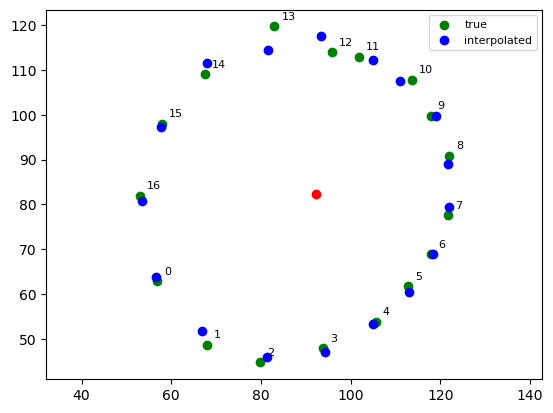

mean error (pixel): 2.06


In [6]:
test_single_frame_polar_interpolation(gt_pts, 2)

In [33]:
polar_interpolated_err = eval_interpolation(polar_interpolate, gt_pts[:3], verbose=True)

frame_idx: 0
curr_pt: [56.6  60.88], curr_pt_interpolated: [55.36 62.11], err: 1.76
curr_pt: [68.68 46.74], curr_pt_interpolated: [67.14 49.96], err: 3.57
curr_pt: [80.62 43.69], curr_pt_interpolated: [82.57 44.8 ], err: 2.25
curr_pt: [94.97 47.62], curr_pt_interpolated: [95.52 46.26], err: 1.46
curr_pt: [106.77  53.77], curr_pt_interpolated: [106.43  52.57], err: 1.25
curr_pt: [114.7   60.88], curr_pt_interpolated: [114.47  59.84], err: 1.07
curr_pt: [119.82  67.86], curr_pt_interpolated: [120.35  68.03], err: 0.56
curr_pt: [123.68  76.63], curr_pt_interpolated: [124.35  78.19], err: 1.69
curr_pt: [124.89  89.89], curr_pt_interpolated: [124.35  88.38], err: 1.61
curr_pt: [120.57  99.83], curr_pt_interpolated: [121.9   99.86], err: 1.33
curr_pt: [115.78 108.69], curr_pt_interpolated: [113.57 108.69], err: 2.22
curr_pt: [103.77 114.82], curr_pt_interpolated: [106.35 113.85], err: 2.76
curr_pt: [ 95.96 115.84], curr_pt_interpolated: [ 93.58 117.41], err: 2.85
curr_pt: [ 82.83 116.82], cu

## eval errors

In [5]:
polar_interpolated_err = eval_interpolation(polar_interpolate, gt_pts)

mean = 4.06, std = 2.85, max = 24.04


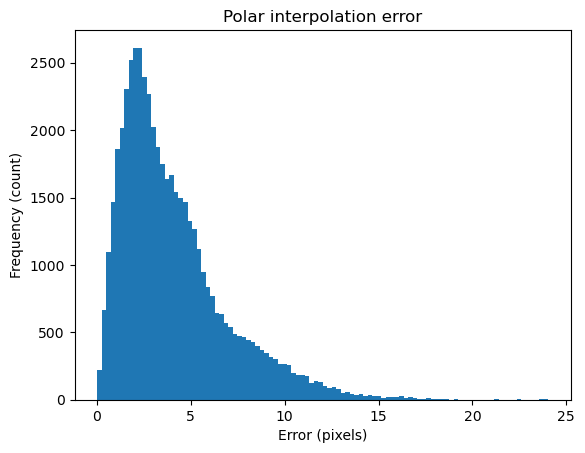

In [11]:
polar_interpolated_err_flat = polar_interpolated_err.flatten()
print(f'mean = {polar_interpolated_err_flat.mean():.2f}, std = {polar_interpolated_err_flat.std():.2f}, max = {polar_interpolated_err_flat.max():.2f}')
plt.hist(polar_interpolated_err_flat, bins=100)
plt.title('Polar interpolation error')
plt.xlabel('Error (pixels)')
plt.ylabel('Frequency (count)')
plt.show()

# Average flow interpolation

In [6]:
gt_pts_reordered = polygon_correction_with_points(gt_pts, poly_4)

In [59]:
gt_pts_reordered.shape

(3000, 17, 2)

In [7]:
def eval_avg_flow_interpolation(pts, window_size=2, reorder=True, verbose=False):
    """
    Evaluate the interpolation performance of a given interpolator.
    
    Args:
        pts: The points to interpolate.
        gt_pts: The ground truth points.
        
    Returns:
        The interpolation error. (frame_cnt, pt_cnt)
    """
    pts = pts[:, :, :2]
    frame_cnt, pt_cnt = pts.shape[:2]
    interpolation_err = np.zeros((frame_cnt, pt_cnt))
    
    for frame_idx in range(frame_cnt):
        if verbose: 
            print(f'frame_idx: {frame_idx}')
        curr_frame_pts = pts[frame_idx]
        gt_pts_copy = pts.copy()
        if reorder:
            polygon_order = poly_4(curr_frame_pts)
            curr_frame_pts = curr_frame_pts[polygon_order]
            gt_pts_copy = gt_pts_copy[:, polygon_order]
        center_pos = curr_frame_pts.mean(axis=0)
        
        for pt_idx in range(pt_cnt):
            
            curr_pt = gt_pts_copy[frame_idx, pt_idx].copy()
            gt_pts_copy[frame_idx, pt_idx] = (0, 0)
            curr_pt_interpolated = avg_flow_interpolate(gt_pts_copy, frame_idx, window_size=window_size, center_pos=center_pos, verbose=False)[pt_idx]
            assert curr_pt.shape == curr_pt_interpolated.shape, f'shape mismatch: {curr_pt.shape} != {curr_pt_interpolated.shape}'
            interpolation_err[frame_idx, pt_idx] = np.linalg.norm(curr_pt - curr_pt_interpolated)
            gt_pts_copy[frame_idx, pt_idx] = curr_pt
            if verbose:
                print(f'curr_pt: {np.round(curr_pt, 2)}, curr_pt_interpolated: {np.round(curr_pt_interpolated, 2)}, err: {np.round(interpolation_err[frame_idx, pt_idx], 2)}')
            
    return interpolation_err

def avg_flow_interpolate(all_frame_pts, frame_idx, window_size=2, center_pos=None, verbose=True):
    """
    Interpolate the points in all_frame_pts using the average displacement method.

    Args:
        all_frame_pts (np.ndarray): The points to interpolate. Shape: (frame_cnt, pt_cnt, 2).
        frame_idx (int): The index of the frame to interpolate.
        window_size (int, optional): The size of the window to use for interpolation (inlusive on both ends). Defaults to 2.
        center_pos (tuple, optional): The center position of the points. Defaults to None.

    Returns:
        np.ndarray: The interpolated points at frame_idx. Shape: (pt_cnt, 2).
    """
    if center_pos is None:
        center_pos = all_frame_pts.mean(axis=0)
    if frame_idx < window_size:
        return polar_interpolate(all_frame_pts[frame_idx], center_pos=center_pos, verbose=verbose)
    
    pt_cnt = all_frame_pts.shape[1]
    curr_frame_pts = all_frame_pts[frame_idx]
    prev_frame_pts = all_frame_pts[frame_idx - 1]
    avg_flow_vecs = (all_frame_pts[frame_idx - 1] - all_frame_pts[frame_idx - window_size]) / (window_size - 1)
    # print(f'avg_flow_vecs: {np.round(avg_flow_vecs, 2)}')
    non_missing_mask = ~(curr_frame_pts == 0).all(axis=1)
    first_non_missing_idx = np.where(non_missing_mask)[0][0]
    curr_frame_pts = np.roll(curr_frame_pts, -first_non_missing_idx, axis=0)
    prev_frame_pts = np.roll(prev_frame_pts, -first_non_missing_idx, axis=0)
    non_missing_mask = np.roll(non_missing_mask, -first_non_missing_idx, axis=0)
    avg_flow_vecs = np.roll(avg_flow_vecs, -first_non_missing_idx, axis=0)
    non_missing_indices = np.where(non_missing_mask)[0]
    
    for pt_idx in range(pt_cnt):
        if non_missing_mask[pt_idx]:
            continue
        prev_idx = non_missing_indices[non_missing_indices < pt_idx][-1] if any(non_missing_indices < pt_idx) else non_missing_indices[-1]
        next_idx = non_missing_indices[non_missing_indices > pt_idx][0] if any(non_missing_indices > pt_idx) else non_missing_indices[0]
        
        if next_idx > prev_idx:
            denom = next_idx - prev_idx
        else:
            denom = pt_cnt - (prev_idx - next_idx)
        weight = ((pt_idx - prev_idx) % pt_cnt) / denom
        # print(f'prev flow vec: {np.round(avg_flow_vecs[prev_idx], 2)}, next flow vec: {np.round(avg_flow_vecs[next_idx], 2)}, weight: {weight}')
        avg_flow = avg_flow_vecs[prev_idx] * weight + avg_flow_vecs[next_idx] * (1 - weight)
        curr_frame_pts[pt_idx] = prev_frame_pts[pt_idx] + avg_flow
    
    curr_frame_pts = np.roll(curr_frame_pts, first_non_missing_idx, axis=0)
    return curr_frame_pts

In [8]:
def test_single_frame_avg_flow_interpolation(gt_pts, frame_idx, window_size=2, reorder=True):
    gt_pts_copy = gt_pts.copy()
    curr_frame_pts = gt_pts[frame_idx]
    if reorder:
        poly_order = poly_4(curr_frame_pts)
        curr_frame_pts = curr_frame_pts[poly_order]
        gt_pts_copy = gt_pts_copy[:, poly_order]
    interp_pts = np.zeros_like(curr_frame_pts)
    
    for pt_idx in range(curr_frame_pts.shape[0]):
        curr_pt = gt_pts_copy[frame_idx, pt_idx].copy()
        gt_pts_copy[frame_idx, pt_idx] = (0, 0)
        interp_pts[pt_idx] = avg_flow_interpolate(gt_pts_copy, frame_idx, window_size=window_size, verbose=False)[pt_idx]
        gt_pts_copy[frame_idx, pt_idx] = curr_pt
    plot_pred_vs_gt_pts(interp_pts, curr_frame_pts)
    mean_err = np.linalg.norm(interp_pts - curr_frame_pts, axis=1).mean()
    print(f'mean error (pixel): {mean_err:.2f}')


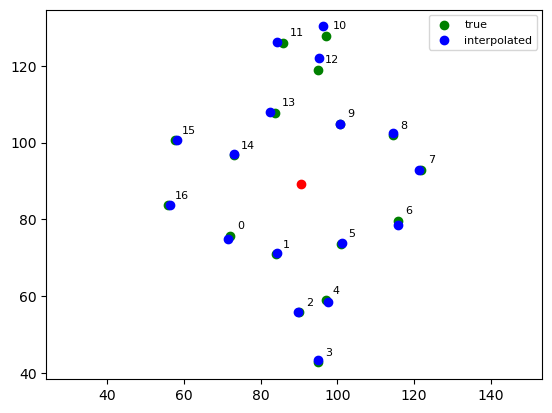

mean error (pixel): 0.92


In [ ]:
test_single_frame_avg_flow_interpolation(gt_pts_reordered, 875)

window size 2: mean = 0.69, std = 0.75, max = 20.08
window size 3: mean = 0.63, std = 0.69, max = 20.04
window size 4: mean = 0.62, std = 0.68, max = 20.05
window size 5: mean = 0.62, std = 0.67, max = 20.18
window size 6: mean = 0.62, std = 0.67, max = 20.20
window size 7: mean = 0.63, std = 0.67, max = 20.20
window size 8: mean = 0.63, std = 0.68, max = 20.31


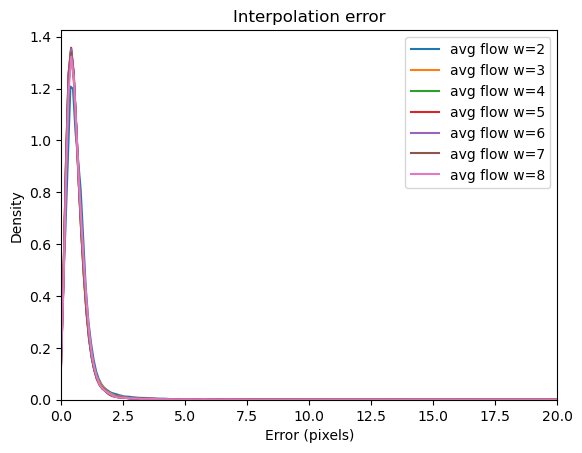

In [37]:
for window_size in range(2, 9):
    avg_flow_err_w = eval_avg_flow_interpolation(gt_pts_reordered, window_size=window_size)
    avg_flow_err_flat_w = avg_flow_err_w.flatten()
    print(f'window size {window_size}: mean = {avg_flow_err_flat_w.mean():.2f}, std = {avg_flow_err_flat_w.std():.2f}, max = {avg_flow_err_flat_w.max():.2f}')
    # plt.hist(avg_flow_err_flat_w, bins=100, label=f'avg flow w={window_size}')
    sns.kdeplot(avg_flow_err_flat_w, label=f'avg flow w={window_size}')
plt.legend()
plt.title('Interpolation error')
plt.xlabel('Error (pixels)')
plt.xlim(0, 20)
plt.show()

In [10]:
avg_flow_interpolated_err = eval_avg_flow_interpolation(gt_pts_reordered, window_size=4)

In [11]:
err_gt_10 = np.where((avg_flow_interpolated_err > 10).any(axis=1))[0]
for frame_idx in err_gt_10:
    print(f'frame_idx: {frame_idx}, max err: {avg_flow_interpolated_err[frame_idx].max():.2f}')

frame_idx: 41, max err: 10.10
frame_idx: 352, max err: 10.05
frame_idx: 414, max err: 12.10
frame_idx: 416, max err: 10.06
frame_idx: 417, max err: 10.89
frame_idx: 743, max err: 16.53
frame_idx: 746, max err: 15.82
frame_idx: 864, max err: 16.44
frame_idx: 871, max err: 19.21
frame_idx: 872, max err: 16.42
frame_idx: 875, max err: 19.22
frame_idx: 927, max err: 17.15
frame_idx: 932, max err: 18.91
frame_idx: 1286, max err: 10.12
frame_idx: 1335, max err: 10.58


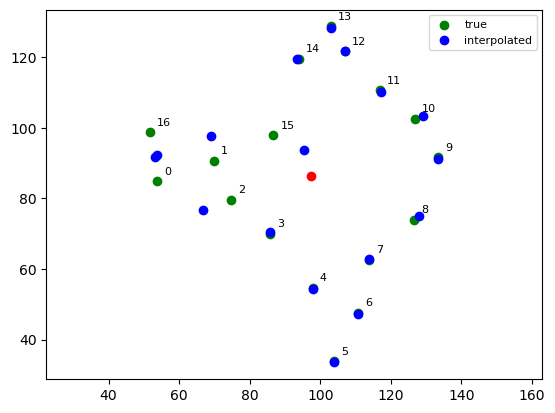

mean error (pixel): 3.88


In [28]:
test_single_frame_avg_flow_interpolation(gt_pts_reordered, 872)

Avg flow: mean = 0.62, std = 0.68, max = 20.05


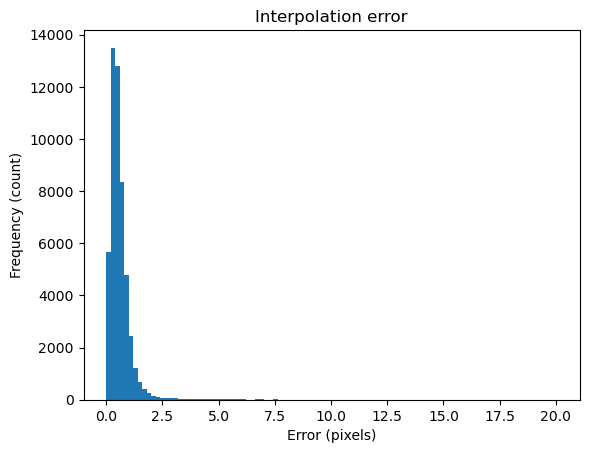

In [20]:
avg_flow_interpolated_err_flat = avg_flow_interpolated_err.flatten()
print(f'Avg flow: mean = {avg_flow_interpolated_err_flat.mean():.2f}, std = {avg_flow_interpolated_err_flat.std():.2f}, max = {avg_flow_interpolated_err_flat.max():.2f}')
# print(f'Polar: mean = {polar_interpolated_err_flat.mean():.2f}, std = {polar_interpolated_err_flat.std():.2f}, max = {polar_interpolated_err_flat.max():.2f}')
plt.hist(avg_flow_interpolated_err_flat, bins=100, label='avg flow')
# plt.hist(polar_interpolated_err_flat, bins=100, label='polar')
# plt.legend()
plt.title('Interpolation error')
plt.xlabel('Error (pixels)')
plt.ylabel('Frequency (count)')
plt.show()

Avg flow: mean = 0.62, std = 0.68, max = 20.05
Polar: mean = 4.06, std = 2.85, max = 24.04


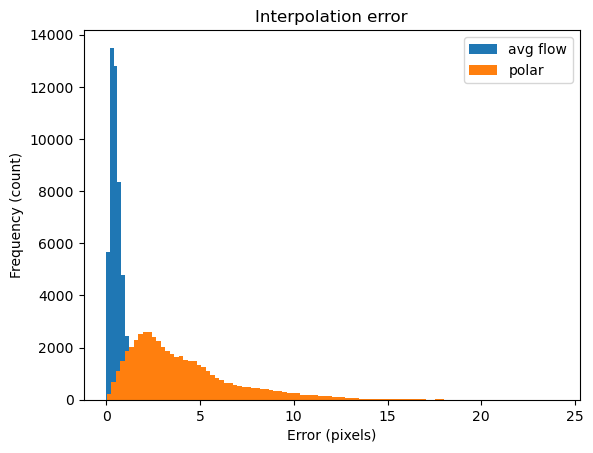

In [21]:
avg_flow_interpolated_err_flat = avg_flow_interpolated_err.flatten()
print(f'Avg flow: mean = {avg_flow_interpolated_err_flat.mean():.2f}, std = {avg_flow_interpolated_err_flat.std():.2f}, max = {avg_flow_interpolated_err_flat.max():.2f}')
print(f'Polar: mean = {polar_interpolated_err_flat.mean():.2f}, std = {polar_interpolated_err_flat.std():.2f}, max = {polar_interpolated_err_flat.max():.2f}')
plt.hist(avg_flow_interpolated_err_flat, bins=100, label='avg flow')
plt.hist(polar_interpolated_err_flat, bins=100, label='polar')
plt.legend()
plt.title('Interpolation error')
plt.xlabel('Error (pixels)')
plt.ylabel('Frequency (count)')
plt.show()

Avg flow interpolation: 
mean = 0.62, std = 0.68, max = 20.05
Polar coords interpolation: 
mean = 4.06, std = 2.85, max = 24.04


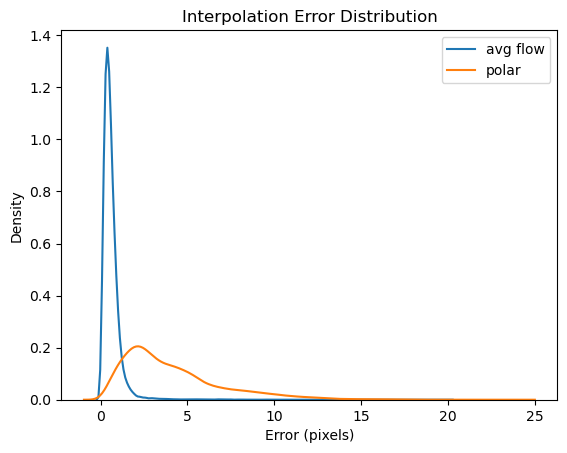

In [22]:
import seaborn as sns  # Add this import at the top if not already present

# ... existing code ...

# avg_flow_interpolated_err_flat = avg_flow_interpolated_err.flatten()
print(f'Avg flow interpolation: \nmean = {avg_flow_interpolated_err_flat.mean():.2f}, std = {avg_flow_interpolated_err_flat.std():.2f}, max = {avg_flow_interpolated_err_flat.max():.2f}')
print(f'Polar coords interpolation: \nmean = {polar_interpolated_err_flat.mean():.2f}, std = {polar_interpolated_err_flat.std():.2f}, max = {polar_interpolated_err_flat.max():.2f}')

# Plot KDE curves instead of histograms
sns.kdeplot(data=avg_flow_interpolated_err_flat, label='avg flow')
sns.kdeplot(data=polar_interpolated_err_flat, label='polar')
plt.legend()
plt.title('Interpolation Error Distribution')
plt.xlabel('Error (pixels)')
plt.ylabel('Density')
plt.show()